## Main notebook script for PV shadow analysis.

Uses the refactored pv_analysis module with:
  - SiteConfig with inverter_utc_offset_hours=3 (confirmed fixed UTC+3)
  - Pre-smoothed shadow matrix (done once)
  - Beam/diffuse separated shadow attenuation
  - Robust timezone handling (no magic-number offsets)
  - No duplicate evaluation loops
  - Validated inverter data loading with gap reporting

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MANUSCRIPT_FIG_DIR = Path("/Users/hdong/Projects/VoxSolaris_Article/figs")
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
})


from pv_analysis_re import (
    SiteConfig,
    find_clear_days,
    load_and_smooth_shadow_matrix,
    load_extra_data_csv,
    load_inverter_data,
    pv_analysis,
    _plot_day_comparison,
    compute_metrics,
    evaluate_performance,
    print_performance_summary,
    plot_real_vs_predicted_scatter,
    save_all_day_plots,
    calculate_api_grid,
    plot_api_map,
)

# Project modules (unchanged)
from shadow_matrix_simulation_re import create_shadow_matrix
# from plot_radiation_day import plot_radiation_day
# from batch_day_plots import batch_radiation_plots, batch_day_plots
try:
    from visual_utils import plot_shadow_matrix_with_sunpaths
except ImportError:
    plot_shadow_matrix_with_sunpaths = None

In [2]:
cfg = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=12.0,
    azimuth_deg=170.0,
    nominal_power_kw=3.96,  # 15% derating for system losses (cabling, inverter inefficiency, etc.)
    system_efficiency=0.8,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,  # Fronius Symo logs in fixed UTC+3
    forecast_shift_minutes=-30, # Shift forecasts 30 minutes earlier to better align with measured data
    window_size=(3, 3),
    interval="5min",
    interval_minutes=5.0,
)

# --- File Paths ---
RAD_FILE       = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TEMP_WIND_FILE = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
CLEAR_MINUTES  = "data/Clear_sky_minutes_kuopio_RH16.txt"
PV_EXCEL       = "data/pvdata/pv_21.xlsx"

LIDAR_FILE     = "output/reclassified_final_v5.laz"
SHADOW_DIR     = "results/shadow_matrix_results_SE_pro"
SHADOW_FN      = "shadow_attenuation_matrix_conecasting_SE_v10.csv"
SHADOW_CSV     = f"{SHADOW_DIR}/{SHADOW_FN}"
EXTRA_DATA_DIR = "output"

In [3]:
import pvlib

def replace_dni_with_computed(df_extra, latitude, longitude):
    """
    Replace CAMS DNI with DNI computed from GHI, DHI, and solar zenith.
    Uses pvlib closure: DNI = (GHI - DHI) / cos(zenith)
    """
    solpos = pvlib.solarposition.get_solarposition(
        df_extra.index, latitude, longitude
    )
    zenith = solpos["apparent_zenith"]

    dni_computed = pvlib.irradiance.dni(
        ghi=df_extra["ghi"],
        dhi=df_extra["dhi"],
        zenith=zenith,
        # clearsky_dni=None,       # no clearsky limit
        # clearsky_tolerance=1.1,
    )

    df_extra["dni_cams"] = df_extra["dni"].copy()  # keep original
    df_extra["dni"] = dni_computed.clip(lower=0)

    return df_extra

In [4]:
def _load_cached_extra(date_obj):
    df = load_extra_data_csv(f"output/extra_data_{date_obj}.csv")
    df = replace_dni_with_computed(df, cfg.latitude, cfg.longitude)
    return df

In [5]:
# %% --- 3. Create Shadow Matrix (ray-tracing — slow, run once) ---
# Uncomment to regenerate:
# shadow_matrix_raw = create_shadow_matrix(
#     lidar_file_path=LIDAR_FILE, voxel_size=2.0,
#     output_dir=SHADOW_DIR, output_fn=SHADOW_FN,
#     offset_from_roof=-0.5, skip_dist=3.0,
# )


# %% --- 4. Load & Pre-smooth Shadow Matrix (done ONCE) ---
shadow_matrix = load_and_smooth_shadow_matrix(SHADOW_CSV, window_size=cfg.window_size)
print(f"Shadow matrix shape: {shadow_matrix.shape}  (altitude x azimuth)")

Shadow matrix shape: (91, 361)  (altitude x azimuth)


Loading shadow matrix...
Calculating seasonal sun paths...


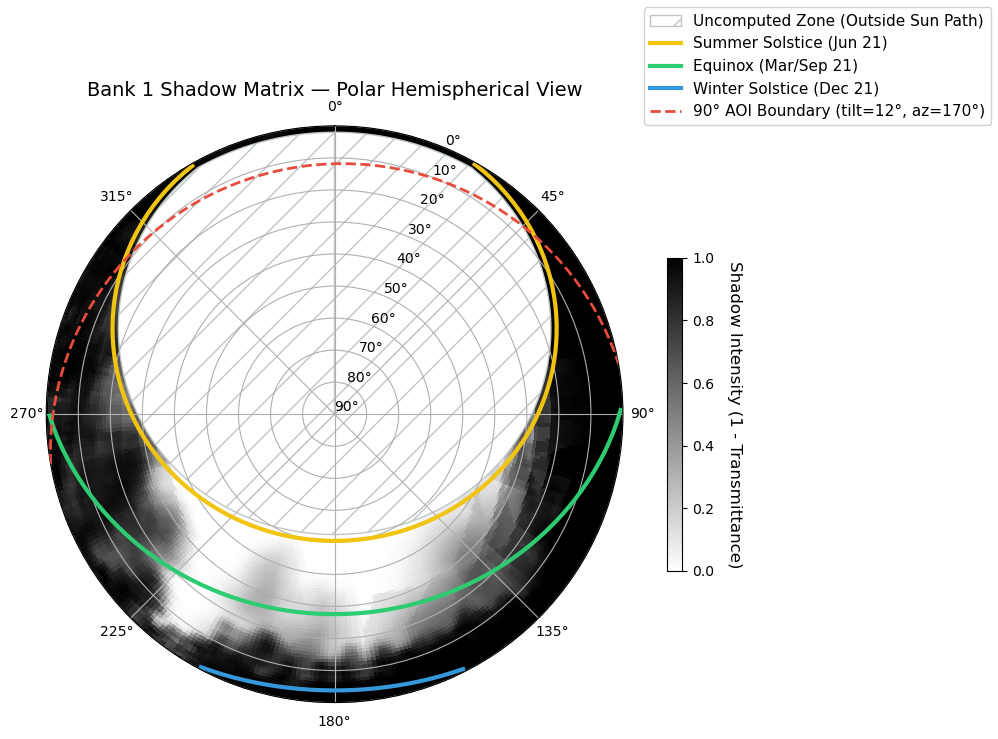

In [6]:
# %% --- 5. Visualise Shadow Matrix ---

if plot_shadow_matrix_with_sunpaths is not None:
    plot_shadow_matrix_with_sunpaths(
        SHADOW_CSV,
        fill_missing=True,
        save_path=str(MANUSCRIPT_FIG_DIR / "SAM_bank1.png"),
        show=True,
        dpi=300,
    )


In [7]:
# %% --- 6. Load Inverter Data ---
pv_df = load_inverter_data(PV_EXCEL, expected_interval_min=cfg.interval_minutes)
print(f"Range: {pv_df['Timestamp'].min()} -> {pv_df['Timestamp'].max()}")
print(pv_df.head())

Inverter data: 102,263 records, 102235/102262 normal intervals, 27 gaps
  Largest gaps: [965. 925. 905. 875. 825.] min
Range: 2021-01-01 00:00:00 -> 2021-12-31 23:55:00
            Timestamp  Energy_Wh  Power_W
0 2021-01-01 00:00:00        0.0      0.0
1 2021-01-01 00:05:00        0.0      0.0
2 2021-01-01 00:10:00        0.0      0.0
3 2021-01-01 00:15:00        0.0      0.0
4 2021-01-01 00:20:00        0.0      0.0


In [8]:
# %% --- 10. Multi-Day Batch Evaluation ---
# def _load_cached_extra(date_obj):
#     """Load pre-cached extra_data CSV for a date, recomputing albedo."""
#     try:
#         return load_extra_data_csv(
#             f"{EXTRA_DATA_DIR}/extra_data_{date_obj}.csv", cfg=cfg
#         )
#     except FileNotFoundError:
#         print(f"  Warning: No extra data for {date_obj}, skipping.")
#         return None

def _load_cached_extra(date_obj):
    df = load_extra_data_csv(f"output/extra_data_{date_obj}.csv")
    df = replace_dni_with_computed(df, cfg.latitude, cfg.longitude)
    return df


# results_df, all_real, all_pred_shaded, all_pred_base = evaluate_performance(
#     significant_days_df=clear_days,
#     shadow_matrix=shadow_matrix,
#     excel_df=pv_df,
#     extra_data_loader=_load_cached_extra,
#     cfg=cfg,
# )

# print_performance_summary(results_df, real_arr=all_real, base_arr=all_pred_base, shaded_arr=all_pred_shaded)

# if not results_df.empty:
#     plot_real_vs_predicted_scatter(
#         all_real,
#         all_pred_base,
#         title="Real vs. FMI Base Forecast (All Clear Days)",
#         ylabel="FMI Forecast — No Shadows (W)",
#         power_threshold=10.0,
#         save_path=str(MANUSCRIPT_FIG_DIR / "b1_clearsky_scatter_base.png"),
#     )
#     plot_real_vs_predicted_scatter(
#         all_real,
#         all_pred_shaded,
#         title="Real vs. Shadow-Corrected Forecast (All Clear Days)",
#         ylabel="Shadow-Corrected Forecast (W)",
#         power_threshold=10.0,
#         save_path=str(MANUSCRIPT_FIG_DIR / "b1_clearsky_scatter_corr.png"),
#     )

Evaluating 153 days: 2021-05-01 → 2021-09-30


All days: 100%|██████████| 153/153 [00:05<00:00, 29.88it/s]


Per-day results saved to: all_days_metrics_bank1.csv

  OVERALL METRICS — 2021-05-01 to 2021-09-30
  153 days evaluated, 0 skipped, 27240 daytime samples

  Metric                   Baseline  Shadow-Corr  Improvement
  --------------------------------------------------------
  RMSE (W)                    548.9        416.7        24.1%
  MAE (W)                     362.8        247.2        31.9%
  MBE (W)                     202.2        -48.6       closer
  R²                          0.413        0.661       +0.249

  Energy (kWh)             Real       Base  Corrected
  ------------------------------------------------
  Total                  1613.8     2077.4     1505.4
  Error                             +28.7%      -6.7%

  Per-day averages (mean of 153 daily metrics):
  RMSE      Base: 505.9 ± 209.1   Corr: 379.2 ± 160.2
  MAE       Base: 358.1 ± 162.6   Corr: 243.7 ± 96.5
  MBE       Base: 201.7 ± 185.1   Corr: -44.4 ± 112.7
  R²        Base: -0.097 ± 1.104   Corr: 0.356 ± 0.4

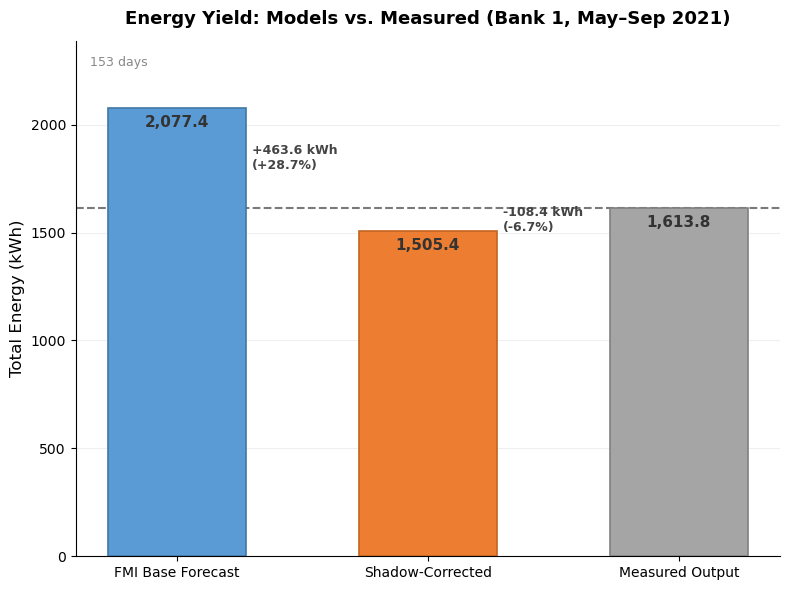

Saved: /Users/hdong/Projects/VoxSolaris_Article/figs/b1_fullperiod_rmse.png


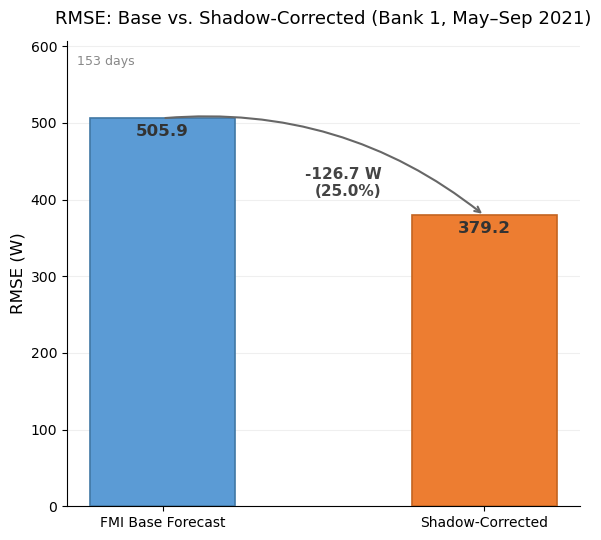

In [9]:
# %% --- 13. Evaluate ALL days May–September (Bank 1) ---
from evaluate_all_days import (
    evaluate_all_days,
    plot_energy_bar_chart as _ead_energy_chart,
    _plot_metric_comparison as _ead_metric_comparison,
)

all_results_b1, all_real_b1, all_base_b1, all_shad_b1 = evaluate_all_days(
    start_date="2021-05-01",
    end_date="2021-09-30",
    shadow_matrix=shadow_matrix,
    excel_df=pv_df,
    extra_data_loader=_load_cached_extra,
    cfg=cfg,
    output_csv="all_days_metrics_bank1.csv",
)

if not all_results_b1.empty:
    _ead_energy_chart(
        all_results_b1,
        title_suffix="Bank 1, May–Sep 2021",
        save_path=str(MANUSCRIPT_FIG_DIR / "b1_fullperiod_energy.png"),
    )
    _ead_metric_comparison(
        all_results_b1["RMSE_Base"].mean(),
        all_results_b1["RMSE_Shaded"].mean(),
        "RMSE",
        "W",
        n_days=len(all_results_b1),
        title_suffix="Bank 1, May–Sep 2021",
        save_path=str(MANUSCRIPT_FIG_DIR / "b1_fullperiod_rmse.png"),
    )
